# FrozenLake Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用规划算法。它的目标是先展示在 FrozenLake 环境中完全随机地选择动作时，智能体通常会得到怎样的结果。这个 baseline 是后续 `Value Iteration` notebook 的参照系，用来帮助读者先建立一个最直观的环境难度印象。

## 环境背景

FrozenLake 是一个离散网格环境。智能体需要从起点移动到终点，但网格中包含多个冰洞，一旦掉进去就会立刻失败。在 `is_slippery=True` 的设置下，动作还带有随机滑动效应，因此即使目标路径很短，也不代表策略可以稳定成功。

## 方法说明

这里的方法非常简单：每一步直接调用 `env.action_space.sample()` 随机选择动作，不记录价值函数，不更新策略，也不利用任何环境模型信息。它不是正式方法，但它能让后面的规划算法结果更有对照意义。

## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是本实验没有神经网络训练，也没有参数更新，主要只是做环境交互和统计汇总。

In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "FrozenLake-v1"
NUM_EPISODES = 5000
MAX_STEPS = 100
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID, is_slippery=True)

## 参数选择说明

- `NUM_EPISODES = 5000`：让随机策略的统计结果更稳定
- `MAX_STEPS = 100`：避免回合过早截断影响观察
- `is_slippery=True`：保留更经典、更困难的随机滑动设置

这个 notebook 的重点不是训练，而是建立随机基线。

In [3]:
episode_rewards = []
episode_lengths = []
successes = []
termination_reasons = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            success = int(reward > 0)
            successes.append(success)
            termination_reasons.append("success" if success else ("truncated" if truncated else "hole"))
            episode_lengths.append(step + 1)
            break
    else:
        successes.append(0)
        termination_reasons.append("max_steps")
        episode_lengths.append(MAX_STEPS)

    episode_rewards.append(total_reward)

env.close()

Random episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
        "termination_reason": termination_reasons,
    }
)
summary.describe(include="all")

,reward,episode_length,success,termination_reason
count,5000.00000,5000.000000,5000.00000,5000
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,hole
freq,NaN,NaN,NaN,4924
mean,0.01520,7.602600,0.01520,NaN
std,0.12236,5.590897,0.12236,NaN
min,0.00000,2.000000,0.00000,NaN
25%,0.00000,4.000000,0.00000,NaN
50%,0.00000,6.000000,0.00000,NaN
75%,0.00000,10.000000,0.00000,NaN


In [5]:
success_rate = float(np.mean(successes))
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))

metrics = pd.DataFrame(
    {
        "metric": ["success_rate", "average_reward", "average_episode_length"],
        "value": [success_rate, avg_reward, avg_length],
    }
)
metrics

,metric,value
0,success_rate,0.0152
1,average_reward,0.0152
2,average_episode_length,7.6026


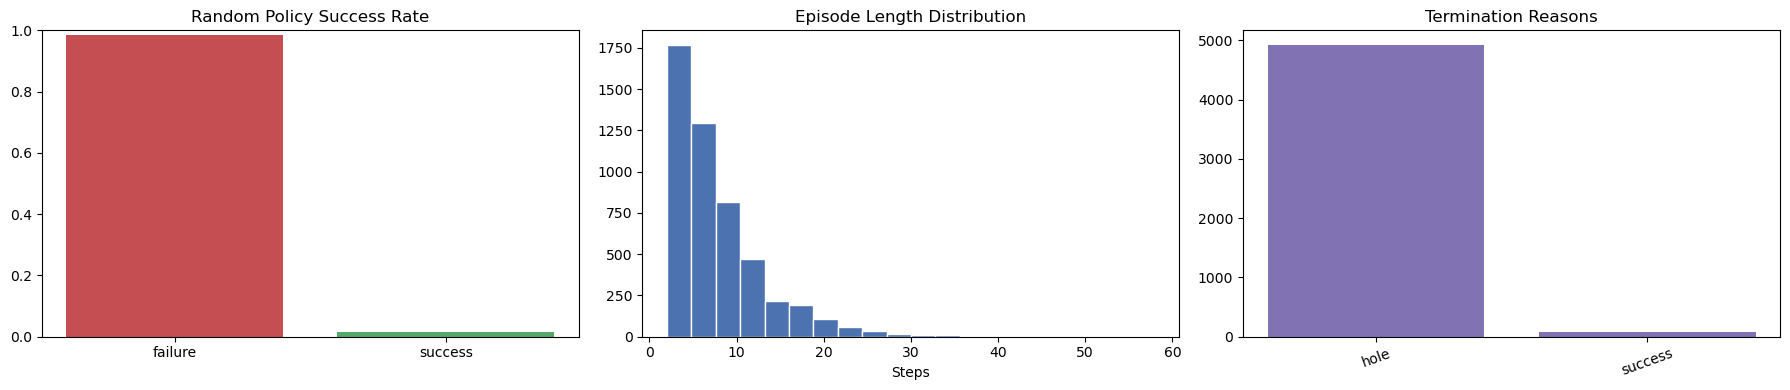

In [6]:
termination_counts = summary["termination_reason"].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(["failure", "success"], [1 - success_rate, success_rate], color=["#c44e52", "#55a868"])
axes[0].set_title("Random Policy Success Rate")
axes[0].set_ylim(0, 1)

axes[1].hist(episode_lengths, bins=20, color="#4c72b0", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].bar(termination_counts.index, termination_counts.values, color="#8172b3")
axes[2].set_title("Termination Reasons")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)

print(f"Success rate: {success_rate:.4f}")
print(f"Average reward: {avg_reward:.4f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Success rate: 0.0152
Average reward: 0.0152
Average episode length: 7.60
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/02-frozenlake-value-iteration/results


## 结果解读

这个 baseline 的重点是说明：在不学习、也不利用环境模型的情况下，FrozenLake 的成功率通常会非常低。这样在进入 `Value Iteration` 后，读者就能更直观地看到规划方法的提升来自哪里。